# 09 · Sensitivity analysis
> All promotion results are **scenario-based simulations under stated assumptions**. Online Retail II has no promotion treatment/control, so nothing here is a causal uplift, ROI or observed revenue lift.

In [1]:
import os, pathlib
os.chdir(pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd())
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from IPython.display import Image, display
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
from retail_targeting.config import load_config
cfg = load_config()
T = lambda name: pd.read_csv(f"outputs/tables/{name}")

In [2]:
T('sensitivity_dominance.csv')

,lift_structure,n_points,share_D_gt_B,share_D_ge_C,share_D_gt_E,share_D_positive,share_D_targets_nobody,evaluation_split
0,constant,1080,1.0,1.0,0.838889,0.273148,0.672222,test
1,persuadable,1080,1.0,1.0,0.875000,0.238889,0.733333,test


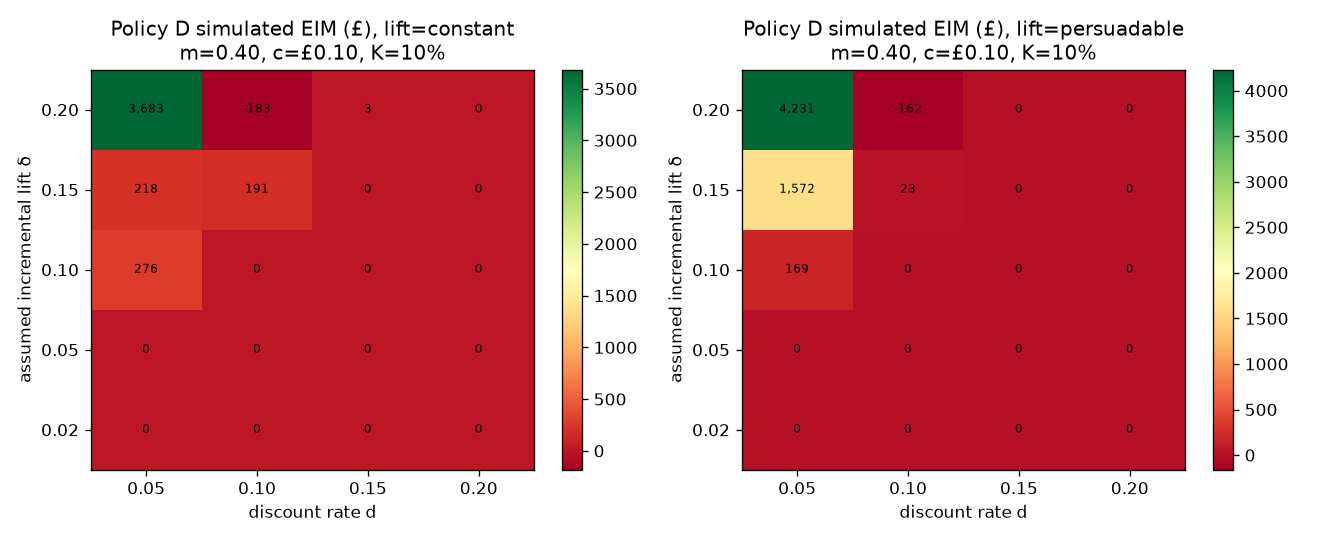

In [3]:
display(Image('outputs/figures/sensitivity_heatmap.png'))

In [4]:
r = T('sensitivity_results.csv'); d = r[r.valid & (r.policy=='D') & r.value_cap & (r.capacity_fractions==0.1) & (r.gross_margin==0.4) & (r.contact_cost==0.1)]
d.pivot_table(index=['lift_structure','incremental_lift'], columns='discount_rate', values='target_count')

discount_rate                     0.05   0.10  0.15  0.20
lift_structure incremental_lift                          
constant       0.02                0.0    0.0   0.0   0.0
               0.05                0.0    0.0   0.0   0.0
               0.10              551.0    0.0   0.0   0.0
               0.15              551.0  189.0   0.0   0.0
               0.20              551.0  551.0   3.0   0.0
persuadable    0.02                0.0    0.0   0.0   0.0
               0.05                0.0    0.0   0.0   0.0
               0.10              551.0    0.0   0.0   0.0
               0.15              551.0  137.0   0.0   0.0
               0.20              551.0  551.0   0.0   0.0

In [5]:
T('sensitivity_calibration_shift.csv').query('capacity_fraction==0.1')[['p_shift','lift_structure','policy','target_count','simulated_eim']]

,p_shift,lift_structure,policy,target_count,simulated_eim
5,-0.117615,constant,A,0.0,0.000000
6,-0.117615,constant,B,551.0,-11043.962691
7,-0.117615,constant,C,551.0,-27968.149644
8,-0.117615,constant,D,0.0,0.000000
9,-0.117615,constant,E,551.0,-1361.556175
20,0.000000,constant,A,0.0,0.000000
21,0.000000,constant,B,551.0,-11043.962691
22,0.000000,constant,C,551.0,-27968.149644
23,0.000000,constant,D,0.0,0.000000
24,0.000000,constant,E,551.0,-1361.556175


Targeting becomes profitable only when the assumed lift is large relative to the discount (e.g. δ ≥ 10 pp with d = 5%). The rule never loses more than random or RFM targeting in any grid point.